In [40]:
pip install pandas matplotlib seaborn statsmodels scipy scikit-learn

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
import scipy
import sklearn

# **Part 1: Stationarity Check & Transformation**
Section Requirement: A short markdown section in your notebook summarising each diagnostic and stating whether the raw series is stationary. If not, show the transformed series and confirm stationarity post-transformation.

## **A1: Load & Visualise**

In [42]:
# Load all three CSV files
df1 = pd.read_csv('Energy_Consumption.csv')
df2 = pd.read_csv('KwhConsumptionBlower78_2.csv')
df3 = pd.read_csv('KwhConsumptionBlower78_3.csv')

# Combine all dataframes
df = pd.concat([df1, df2, df3], ignore_index=True)

In [43]:
df

,Unnamed: 0,TxnDate,TxnTime,Consumption
0,76229,01 Jan 2022,16:55:52,1.010
1,76258,01 Jan 2022,21:45:29,0.908
2,76287,01 Jan 2022,12:24:52,0.926
3,76316,01 Jan 2022,04:07:36,0.928
4,76345,01 Jan 2022,06:52:25,0.916
...,...,...,...,...
3601,1743,28 Feb 2022,22:01:52,1.020
3602,1744,28 Feb 2022,08:54:15,0.948
3603,1745,28 Feb 2022,06:26:48,0.912
3604,1746,28 Feb 2022,03:21:12,1.064


In [44]:
df["datetime"] = pd.to_datetime(df["TxnDate"] + " " + df["TxnTime"],
                                format="%d %b %Y %H:%M:%S")

In [45]:
print(df["datetime"].dtype)

datetime64[ns]


In [46]:
df.drop(columns=["TxnDate", "TxnTime", "Unnamed: 0"], inplace=True)

In [47]:
df.sort_values(by="datetime", inplace=True)

In [48]:
df.set_index("datetime", inplace=True)

In [49]:
df

,Consumption
datetime,
2022-01-01 00:22:28,1.030
2022-01-01 00:42:33,0.904
2022-01-01 01:01:51,0.904
2022-01-01 01:41:48,1.850
2022-01-01 02:22:52,1.878
...,...
2022-02-28 22:25:43,1.152
2022-02-28 22:44:37,0.888
2022-02-28 23:07:15,1.064


* Consumption: Energy Consumption in Kilowatt per hour


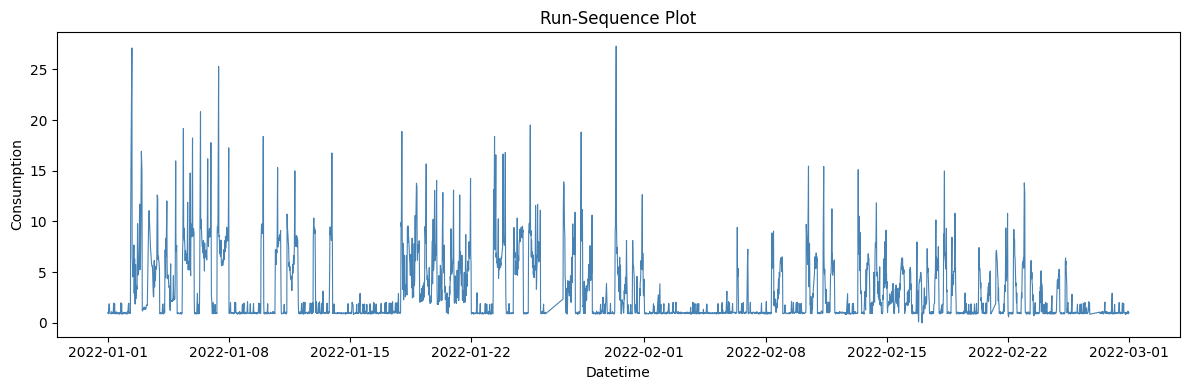

In [50]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df.Consumption, linewidth=0.8, color='steelblue')

plt.title("Run-Sequence Plot")
plt.xlabel("Datetime")
plt.ylabel(df.columns[0])
plt.tight_layout()
plt.show()

### **Question**
* Do you observe a trend, seasonality, or variance drift?
> I can Observe a variance drift. There are times when Power consumption goes down.
* Are there visible outliers
> Yes I can see two to three high power consumption

## **A2: Summary Statistics**

In [51]:
# rolling mean
df["rolling_mean_12"] = df.Consumption.rolling(window=12).mean()

In [52]:
# rolling standard deviation
df["rolling_std_12"] = df.Consumption.rolling(window=12).std()

In [53]:
print(df.head(20))

                     Consumption  rolling_mean_12  rolling_std_12
datetime                                                         
2022-01-01 00:22:28        1.030              NaN             NaN
2022-01-01 00:42:33        0.904              NaN             NaN
2022-01-01 01:01:51        0.904              NaN             NaN
2022-01-01 01:41:48        1.850              NaN             NaN
2022-01-01 02:22:52        1.878              NaN             NaN
2022-01-01 02:47:00        1.092              NaN             NaN
2022-01-01 03:06:30        0.924              NaN             NaN
2022-01-01 03:27:40        0.944              NaN             NaN
2022-01-01 03:47:47        0.920              NaN             NaN
2022-01-01 04:07:36        0.928              NaN             NaN
2022-01-01 04:28:02        0.944              NaN             NaN
2022-01-01 04:48:02        0.896         1.101167        0.360909
2022-01-01 05:07:43        0.930         1.092833        0.363845
2022-01-01

### **Question**
* Is the rolling mean roughly horizontal?
> Yes, although it goes down slightly
* Does the rolling std stay roughly constant?
>No, it stays constant on 0.3 and 0.06

## **A3: Histogram + KDE**

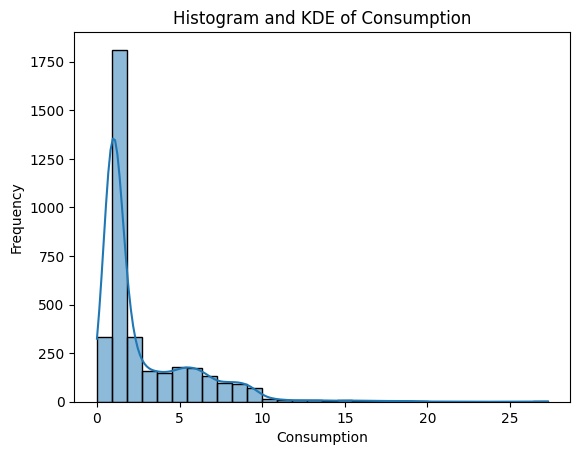

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute histogram values
counts, bins = np.histogram(df.Consumption.dropna(), bins=30)

# Find highest frequency
max_count = counts.max()
max_bin_index = counts.argmax()

# Bin center
bin_center = (bins[max_bin_index] + bins[max_bin_index + 1]) / 2

# Plot
sns.histplot(df.Consumption, kde=True, bins=30)

plt.title("Histogram and KDE of Consumption")
plt.xlabel("Consumption")
plt.ylabel("Frequency")

plt.show()

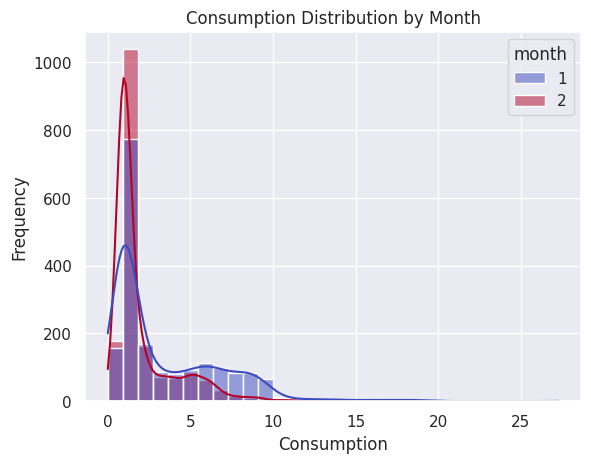

In [100]:
df["month"] = df.index.month

sns.histplot(data=df, x="Consumption", hue="month", bins=30, kde=True,
             palette="coolwarm")

plt.title("Consumption Distribution by Month")
plt.xlabel("Consumption")
plt.ylabel("Frequency")

plt.show()

In [55]:
mode_value = df["Consumption"].mode()[0]
print("Most frequent value:", mode_value)

Most frequent value: 0.94


###**Question:**
Is the distribution stable across sub-periods?
> Somehow, the distribution of the sub-periods were kinda similar except for their highest frequency of 0.94

## **A4: ADF Test**

In [56]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df.Consumption.dropna())

print("ADF Statistic: ", result[0])
print("p-value:       ", result[1])
print("Lags Used:     ", result[2])
print("Obs Used:      ", result[3])
print("\nCritical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

ADF Statistic:  -6.395049621660132
p-value:        2.0606770323104993e-08
Lags Used:      26
Obs Used:       3579

Critical Values:
   1%: -3.4322
   5%: -2.8623
   10%: -2.5672


> According to the ADF test. The Time series data is already stationary because the ADF value is negative, -6.3950. Its p-value is also less than 0.05, therefore we reject the null hypothesis (the series has a unit root (non-stationary)), which means the data is Stationary. Even on the critical values, the stationarity of the time-series is confident at 99%, 95%, and 90% confidence level because they are all greater than -6.3950.

### **Question:** At the 5 % level, do you reject H₀ (unit root) or not?
> Yes, because as I stated earlier the value at 95% confidence level is still greater than -6.3950 which is -2.8623

# Part 2: Classical Forecasting Models
**Section Requirement:** Plots of forecasts vs. actuals, a table of error metrics (train/test split), and a concise discussion (≈ 150 words) explaining performance differences.

## 1. Hold-out split – last 20 % of observations → test set.

In [57]:
# Hold-out split — last 20% as test set
split_index = int(len(df) * 0.80)

train = df.iloc[:split_index]
test  = df.iloc[split_index:]

print(f"Total observations : {len(df1)}")
print(f"Train size: {len(train)} ({len(train)/len(df)*100:.2f}%)")
print(f"Test size: {len(test)}  ({len(test)/len(df)*100:.2f}%)")
print(f"\nTrain period: {train.index[0]} → {train.index[-1]}")
print(f"Test period : {test.index[0]} → {test.index[-1]}")

Total observations : 1228
Train size: 2884 (79.98%)
Test size: 722  (20.02%)

Train period: 2022-01-01 00:22:28 → 2022-02-16 22:25:40
Test period : 2022-02-16 22:48:34 → 2022-02-28 23:50:27


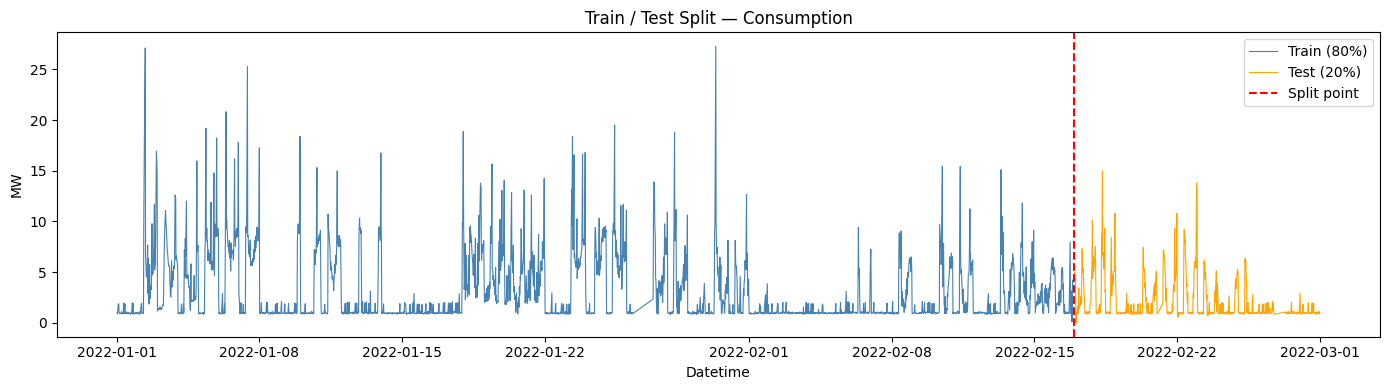

In [58]:
plt.figure(figsize=(14, 4))
plt.plot(train.index, train.Consumption, label="Train (80%)", color="steelblue", linewidth=0.8)
plt.plot(test.index,  test.Consumption,  label="Test (20%)",  color="orange",    linewidth=0.8)
plt.axvline(x=test.index[0], color="red", linestyle="--", label="Split point")
plt.title("Train / Test Split — Consumption")
plt.xlabel("Datetime")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.show()

## Model 1: Smoothing – use Simple Moving Average (window = optimal via grid-search) or SES as baseline.

In [59]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Grid search over window sizes
windows = range(2, 49)  # test windows 2–48
results = []

for w in windows:
    # Rolling mean on train, predict on test
    preds = df.Consumption.shift(1).rolling(w).mean().iloc[split_index:]
    actuals = test.Consumption

    # Align (drop NaNs)
    mask = preds.notna()
    rmse = np.sqrt(mean_squared_error(actuals[mask], preds[mask]))
    results.append({"window": w, "rmse": rmse})

results_df = pd.DataFrame(results)
optimal_window = results_df.loc[results_df.rmse.idxmin(), "window"]
print(results_df.sort_values("rmse").head(10))
print(f"\nOptimal Window: {optimal_window}")

    window      rmse
0        2  1.295084
1        3  1.382135
2        4  1.465904
3        5  1.546855
4        6  1.615768
5        7  1.678349
6        8  1.744619
7        9  1.805455
38      40  1.840616
39      41  1.841512

Optimal Window: 2


In [60]:
sma_preds = df.Consumption.shift(1).rolling(optimal_window).mean()\
            .iloc[split_index:]

mask = sma_preds.notna()
sma_preds = sma_preds[mask]
test_aligned = test.Consumption[mask]

In [61]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_model = SimpleExpSmoothing(train.Consumption).fit(optimized=True)
ses_preds = ses_model.forecast(len(test))
ses_preds.index = test.index

In [105]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def get_metrics(actuals, preds, model_name):
    mae  = mean_absolute_error(actuals, preds)
    rmse = mean_squared_error(actuals, preds)
    mask = actuals.values != 0
    mape = np.mean(np.abs((actuals.values[mask] - preds.values[mask]) /
                           actuals.values[mask])) * 100
    return {"Model": model_name, "MAE": round(mae,2), "MSE": round(rmse,2),
            "MAPE(%)": round(mape,2)}

metrics = pd.DataFrame([
    get_metrics(test_aligned, sma_preds, f"SMA (window={optimal_window})"),
    get_metrics(test.Consumption, ses_preds, "SES"),
])
print(metrics.to_string(index=False))

         Model  MAE  MSE  MAPE(%)
SMA (window=2) 0.61 1.68    27.93
           SES 2.82 9.16   250.25


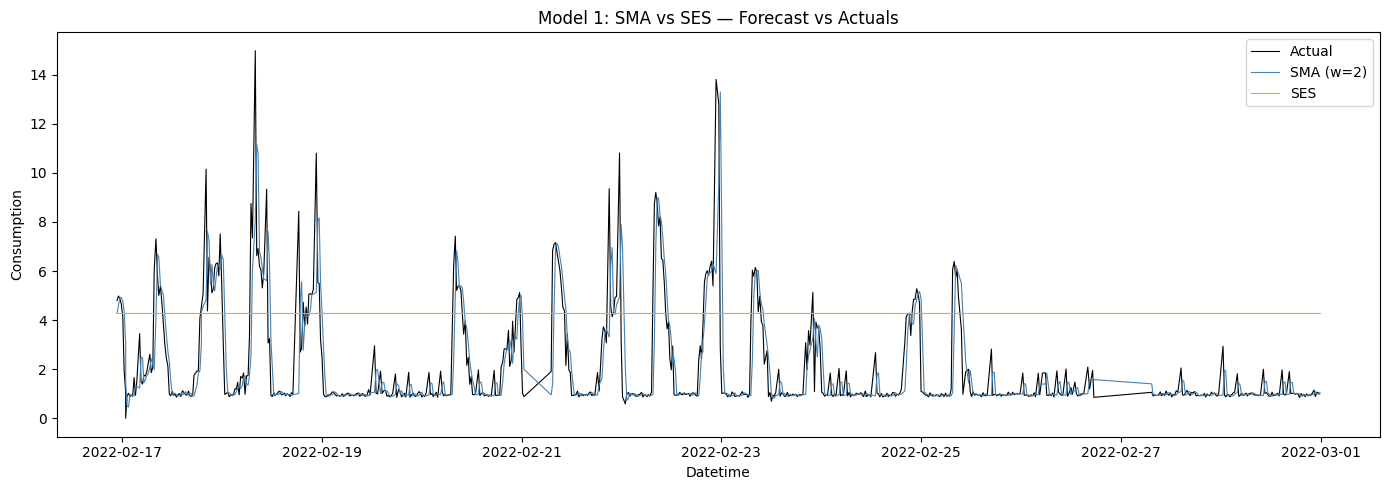

In [63]:
plt.figure(figsize=(14, 5))
plt.plot(test.index, test.Consumption, label="Actual", color="black",
         linewidth=0.8)
plt.plot(sma_preds.index, sma_preds, label=f"SMA (w={optimal_window})",
         color="steelblue", linewidth=0.8)
plt.plot(test.index, ses_preds, label="SES",
         color="orange", linewidth=0.8)
plt.title("Model 1: SMA vs SES — Forecast vs Actuals")
plt.xlabel("Datetime")
plt.ylabel("Consumption")
plt.legend()
plt.tight_layout()
plt.show()

## Model 2: Autoregression (AR-p) – choose p via PACF or AIC minimisation.

<Figure size 1200x400 with 0 Axes>

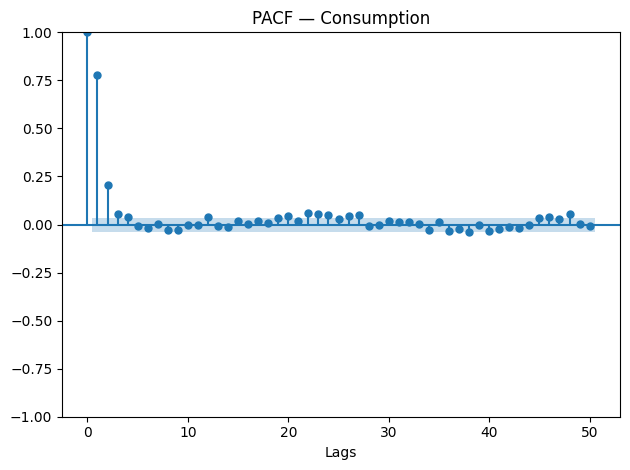

In [64]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12, 4))
plot_pacf(train.Consumption.dropna(), lags=50, method='ywm')
plt.title("PACF — Consumption")
plt.xlabel("Lags")
plt.tight_layout()
plt.show()

In [65]:
import statsmodels.api as sm

aic_results = []

for p in range(1, 20):
    try:
        model = sm.tsa.ARIMA(train.Consumption, order=(p, 0, 0)).fit()
        aic_results.append({"p": p, "AIC": model.aic})
    except:
        continue

aic_df = pd.DataFrame(aic_results)
optimal_p = aic_df.loc[aic_df.AIC.idxmin(), "p"]

print(aic_df.sort_values("AIC").head(10))
print(f"\n Optimal p (AIC): {optimal_p}")

     p           AIC
3    4  11941.885450
4    5  11943.739482
2    3  11943.762051
5    6  11944.867011
8    9  11946.487962
7    8  11946.820357
6    7  11946.861532
11  12  11948.125043
9   10  11948.474773
12  13  11949.973743

 Optimal p (AIC): 4


In [66]:
ar_model = sm.tsa.ARIMA(train.Consumption, order=(optimal_p, 0, 0)).fit()
print(ar_model.summary())

                               SARIMAX Results                                
Dep. Variable:            Consumption   No. Observations:                 2884
Model:                 ARIMA(4, 0, 0)   Log Likelihood               -5964.943
Date:                Mon, 09 Mar 2026   AIC                          11941.885
Time:                        14:29:09   BIC                          11977.687
Sample:                             0   HQIC                         11954.789
                               - 2884                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9665      0.392      7.566      0.000       2.198       3.735
ar.L1          0.6040      0.009     70.773      0.000       0.587       0.621
ar.L2          0.1659      0.014     11.923      0.0

In [68]:
ar_pred_obj = ar_model.apply(test.Consumption).get_prediction(
    start=test.index[0],
    end=test.index[-1],
    dynamic=False
)
ar_preds = ar_pred_obj.predicted_mean
ar_preds.index = test.index

In [107]:
ar_metrics = get_metrics(test.Consumption, ar_preds, f"AR(p={optimal_p})")
print(pd.DataFrame([ar_metrics]))

     Model   MAE   MSE  MAPE(%)
0  AR(p=1)  0.75  1.53    47.45


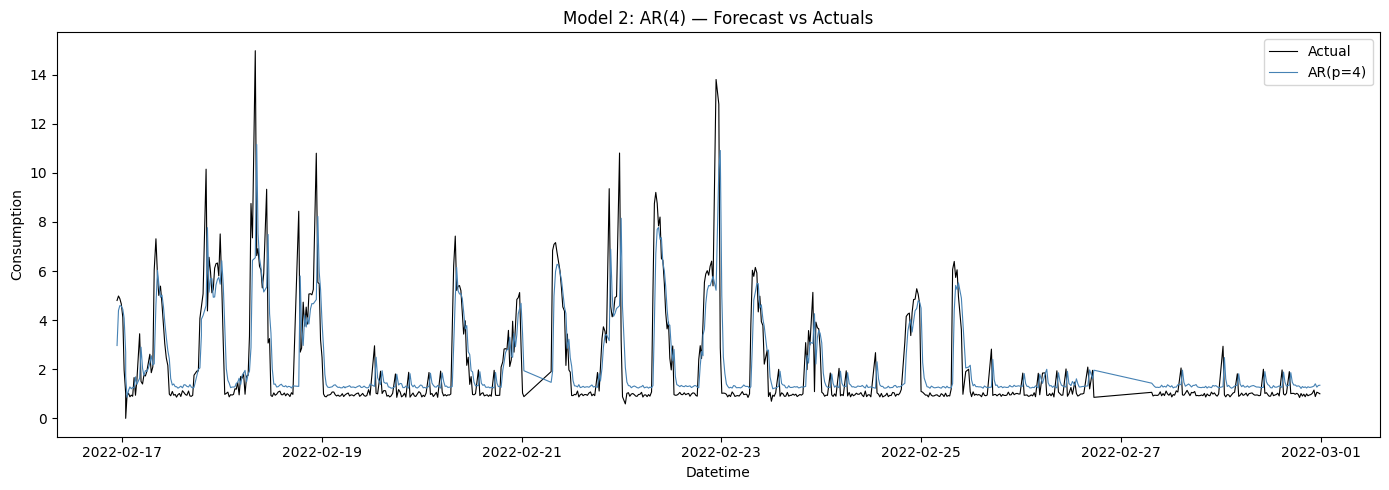

In [70]:
plt.figure(figsize=(14, 5))
plt.plot(test.index,  test.Consumption, label="Actual",             color="black",    linewidth=0.8)
plt.plot(ar_preds.index, ar_preds,    label=f"AR(p={optimal_p})", color="steelblue",linewidth=0.8)
plt.title(f"Model 2: AR({optimal_p}) — Forecast vs Actuals")
plt.xlabel("Datetime")
plt.ylabel("Consumption")
plt.legend()
plt.tight_layout()
plt.show()

## Model 3: ARIMA(p,d,q) – use auto_arima (or manual grid search) on the stationary series.

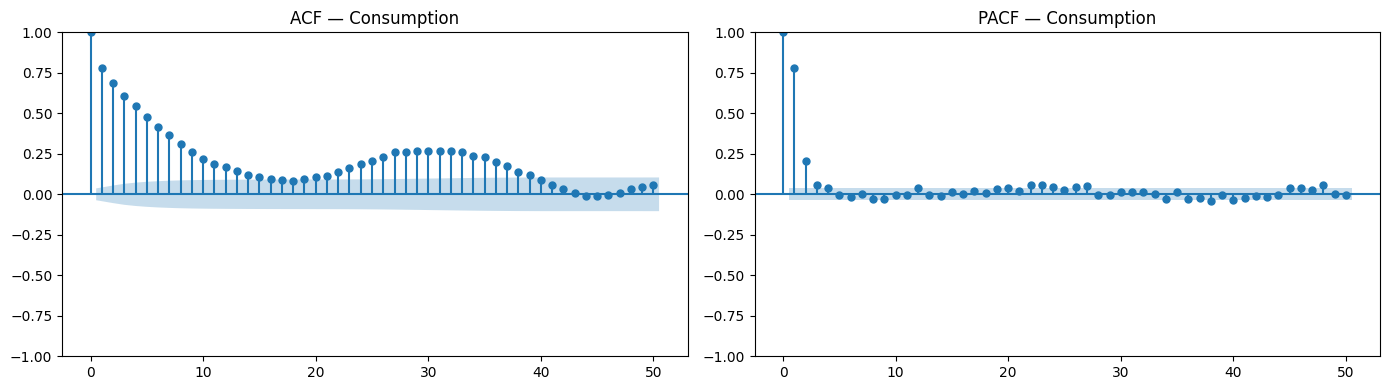

In [71]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(train.Consumption.dropna(),  lags=50, ax=axes[0])
plot_pacf(train.Consumption.dropna(), lags=50, method='ywm', ax=axes[1])

axes[0].set_title("ACF — Consumption")
axes[1].set_title("PACF — Consumption")
plt.tight_layout()
plt.show()

In [72]:
import itertools
import warnings
warnings.filterwarnings("ignore")

p_range = range(0, 4)
d_range = [0]        # already stationary
q_range = range(0, 4)

aic_results = []

for p, d, q in itertools.product(p_range, d_range, q_range):
    try:
        model = sm.tsa.ARIMA(train.Consumption, order=(p, d, q)).fit()
        aic_results.append({"p": p, "d": d, "q": q, "AIC": round(model.aic, 2)})
    except:
        continue

aic_df = pd.DataFrame(aic_results).sort_values("AIC")
print(aic_df.head(10))

best = aic_df.iloc[0]
optimal_p, optimal_d, optimal_q = int(best.p), int(best.d), int(best.q)
print(f"\nOptimal Order: ARIMA({optimal_p}, {optimal_d}, {optimal_q})")

    p  d  q       AIC
5   1  0  1  11939.50
6   1  0  2  11941.45
9   2  0  1  11941.45
7   1  0  3  11943.36
13  3  0  1  11943.42
10  2  0  2  11943.49
12  3  0  0  11943.76
15  3  0  3  11944.57
11  2  0  3  11944.83
14  3  0  2  11944.95

Optimal Order: ARIMA(1, 0, 1)


In [73]:
arima_model = sm.tsa.ARIMA(
    train.Consumption,
    order=(optimal_p, optimal_d, optimal_q)
).fit()

print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:            Consumption   No. Observations:                 2884
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -5965.750
Date:                Mon, 09 Mar 2026   AIC                          11939.500
Time:                        14:32:33   BIC                          11963.367
Sample:                             0   HQIC                         11948.102
                               - 2884                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9661      0.383      7.739      0.000       2.215       3.717
ar.L1          0.8839      0.010     91.572      0.000       0.865       0.903
ma.L1         -0.2808      0.013    -22.139      0.0

In [74]:
arima_pred_obj = arima_model.apply(test.Consumption).get_prediction(
    start=test.index[0],
    end=test.index[-1],
    dynamic=False
)
arima_preds = arima_pred_obj.predicted_mean

arima_preds.index = test.index

In [106]:
arima_metrics = get_metrics(
    test.Consumption, arima_preds,
    f"ARIMA({optimal_p},{optimal_d},{optimal_q})"
)
print(pd.DataFrame([arima_metrics]))

          Model   MAE  MSE  MAPE(%)
0  ARIMA(1,0,1)  0.71  1.5    42.24


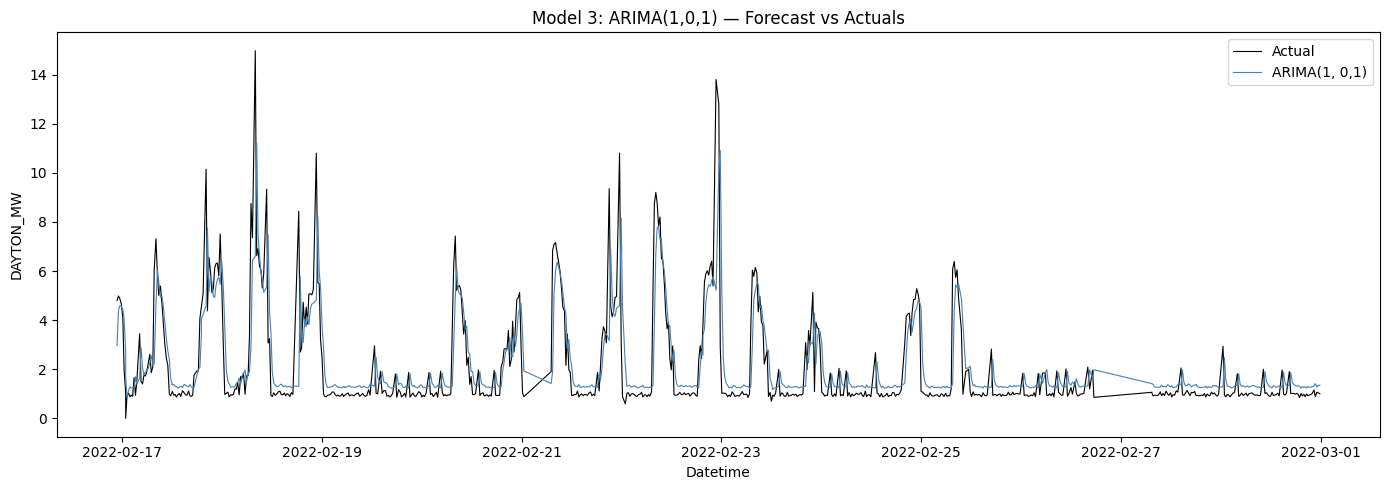

In [76]:
plt.figure(figsize=(14, 5))
plt.plot(test.index, test.Consumption, label="Actual", color="black",
         linewidth=0.8)
plt.plot(arima_preds.index, arima_preds,
         label=f"ARIMA({optimal_p}, {optimal_d},{optimal_q})",
         color="steelblue", linewidth=0.8)
plt.title(f"Model 3: ARIMA({optimal_p},{optimal_d},{optimal_q}) — Forecast vs Actuals")
plt.xlabel("Datetime")
plt.ylabel("DAYTON_MW")
plt.legend()
plt.tight_layout()
plt.show()

## **Questions**:

* Which model captured trend/seasonality best?
> Since my data does not have any trend, the best model that captures seasonality is SMA model based on the Forecast vs Actual.
* Are residuals white-noise (plot residual ACF)?
>Some of the points in the ACF graph were not in the blueband so I think there is still some noise.
* Does a more complex model always lower MSE? Why or why not?
> Yes, but based on the metrics the MSE of ARIMA is 1.5 and MSE of AR-P is 1.53 which is not far off.

# Part 3: Exponential Smoothing Family

**Section Requirement:** Three forecast plots (SES, Holt/DES, Holt-Winters/TES), an error–comparison table, and a paragraph justifying your chosen “best” model.

## SES

In [78]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

# Fit SES
ses_model = SimpleExpSmoothing(train.Consumption).fit(optimized=True)
ses_preds = ses_model.forecast(len(test))
ses_preds.index = test.index

## HOLT/DES

In [79]:
# Fit Holt (Level + Trend)
holt_model = Holt(train.Consumption).fit(optimized=True)
holt_preds = holt_model.forecast(len(test))
holt_preds.index = test.index

## Holt-Winters/TES

In [80]:
# Fit Holt-Winters (Level + Trend + Seasonality)
# seasonal_periods=24 for hourly data (daily cycle)
hw_model = ExponentialSmoothing(
    train.Consumption,
    trend="add",
    seasonal="add",
    seasonal_periods=24
).fit(optimized=True)

hw_preds = hw_model.forecast(len(test))
hw_preds.index = test.index

## Metrics

In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def get_metrics(actuals, preds, model_name):
    mae  = mean_absolute_error(actuals, preds)
    mse  = mean_squared_error(actuals, preds)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actuals.values - preds.values) / actuals.values)) * 100
    return {
        "Model"   : model_name,
        "MAE"     : round(mae,  2),
        "MSE"     : round(mse,  2),
        "RMSE"    : round(rmse, 2),
        "MAPE(%)" : round(mape, 2)
    }

metrics = pd.DataFrame([
    get_metrics(test.Consumption, ses_preds,  "SES"),
    get_metrics(test.Consumption, holt_preds, "Holt (DES)"),
    get_metrics(test.Consumption, hw_preds,   "Holt-Winters (TES)"),
])

print(metrics.to_string(index=False))

             Model  MAE   MSE  RMSE  MAPE(%)
               SES 2.82  9.16  3.03      inf
        Holt (DES) 2.73  8.61  2.93      inf
Holt-Winters (TES) 3.23 12.02  3.47      inf


### Visualization

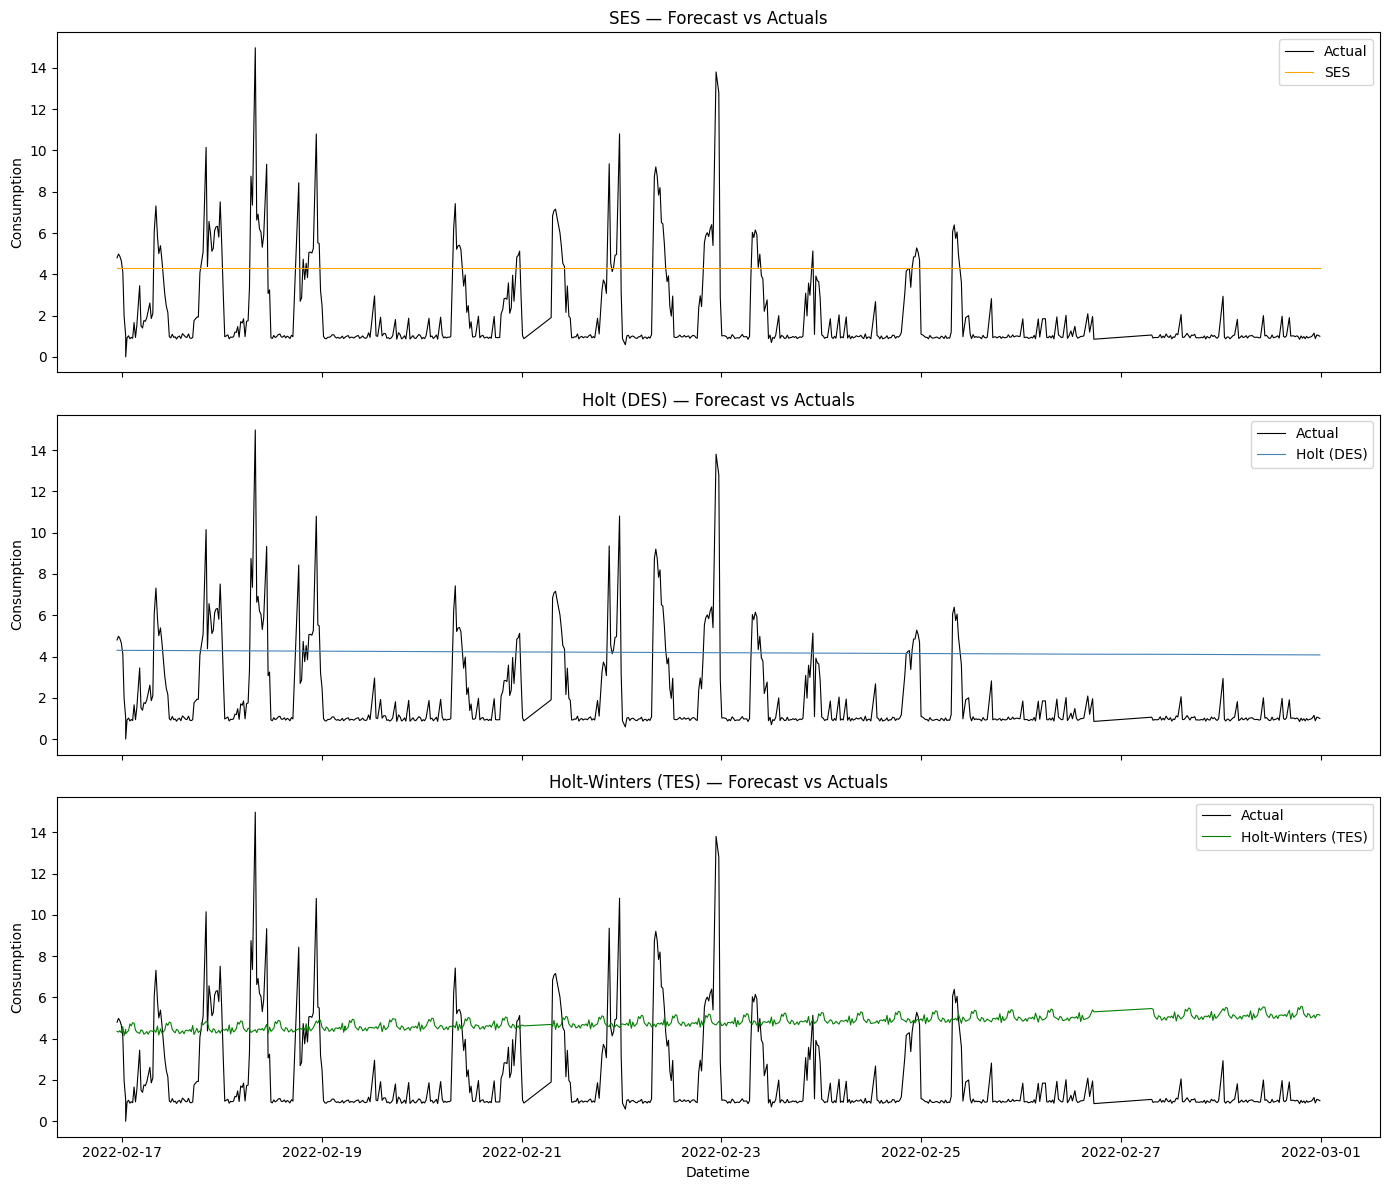

In [85]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

models = [
    (ses_preds,  "SES", "orange"),
    (holt_preds, "Holt (DES)", "steelblue"),
    (hw_preds,   "Holt-Winters (TES)", "green"),
]

for ax, (preds, name, color) in zip(axes, models):
    ax.plot(test.index, test.Consumption, label="Actual", color="black",  linewidth=0.8)
    ax.plot(test.index, preds, label=name,     color=color,    linewidth=0.8)
    ax.set_title(f"{name} — Forecast vs Actuals")
    ax.set_ylabel("Consumption")
    ax.legend()

plt.xlabel("Datetime")
plt.tight_layout()
plt.show()

### Residuals

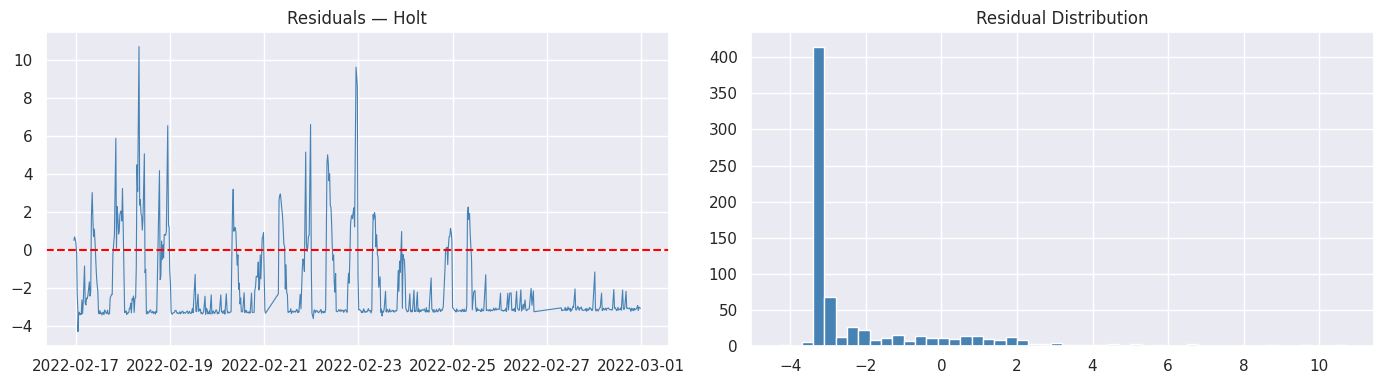

Mean of residuals : -2.1470  (closer to 0 = better)
Std of residuals  : 1.9989


In [111]:
#residuals = test.Consumption.values - ses_preds.values
residuals = test.Consumption.values - holt_preds.values
#residuals = test.Consumption.values - hw_preds.values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(test.index, residuals, color="steelblue", linewidth=0.8)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals — Holt")

axes[1].hist(residuals, bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()

print(f"Mean of residuals : {residuals.mean():.4f}  (closer to 0 = better)")
print(f"Std of residuals  : {residuals.std():.4f}")

## **Questions:**

1. Fit each model on the training set; forecast the test horizon.
2. Compute MSE on the test set for each.
3. Select the variant with the lowest MSE and well-behaved residuals.
> Based on the MSE of SES, Holt, and Holt_winter, Holt has the lowest MSE which is 8.61 with the Mean of Residual of -2.1470.

# Part 4: ACF/PACF Diagnostics & Seasonal Models
**Section Requirement:** ACF/PACF plots, three forecast plots (AR, ARIMA, SARIMA), a comparison table (MSE + AIC), and a summary paragraph.

## ACF & OACF Plots

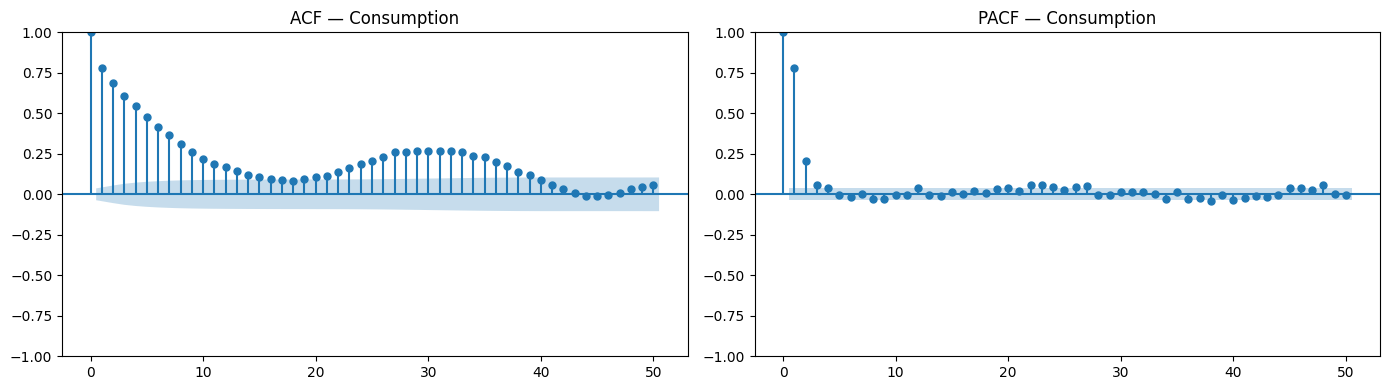

In [88]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train.Consumption.dropna(),  lags=50, ax=axes[0])
plot_pacf(train.Consumption.dropna(), lags=50, method='ywm', ax=axes[1])
axes[0].set_title("ACF — Consumption")
axes[1].set_title("PACF — Consumption")
plt.tight_layout()
plt.show()

## Model A: AR(p)

In [89]:
ar_model    = sm.tsa.ARIMA(train.Consumption, order=(optimal_p, 0, 0)).fit()
ar_pred_obj = ar_model.apply(test.Consumption).get_prediction(
    start=test.index[0], end=test.index[-1], dynamic=False
)
ar_preds = ar_pred_obj.predicted_mean
ar_aic   = ar_model.aic

## Model B: ARIMA(p,d,q)

In [90]:
arima_model    = sm.tsa.ARIMA(train.Consumption, order=(optimal_p, 0, optimal_q)).fit()
arima_pred_obj = arima_model.apply(test.Consumption).get_prediction(
    start=test.index[0], end=test.index[-1], dynamic=False
)
arima_preds = arima_pred_obj.predicted_mean
arima_aic   = arima_model.aic

## Model C: SARIMA

In [91]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# m=24 for hourly data (daily seasonality)
# Start with conservative seasonal terms (1,1,1)
sarima_model = SARIMAX(
    train.Consumption,
    order=(optimal_p, 0, optimal_q),        # non-seasonal (p,d,q)
    seasonal_order=(1, 1, 1, 24)            # seasonal (P,D,Q,m)
).fit(disp=False)

sarima_preds = sarima_model.forecast(steps=len(test))
sarima_preds.index = test.index
sarima_aic   = sarima_model.aic

print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                        Consumption   No. Observations:                 2884
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood               -5972.790
Date:                            Mon, 09 Mar 2026   AIC                          11955.580
Time:                                    14:49:14   BIC                          11985.373
Sample:                                         0   HQIC                         11966.323
                                           - 2884                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8810      0.009     98.189      0.000       0.863       0.899
ma.L1         -0.2770      0.014   

## Comparison Table (MSE + AIC)

In [113]:
from sklearn.metrics import mean_squared_error

def get_full_metrics(actuals, preds, model_name, aic):
    mse  = mean_squared_error(actuals, preds)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(actuals, preds)
    mask = actuals.values != 0
    mape = np.mean(np.abs((actuals.values[mask] - preds.values[mask]) /
                           actuals.values[mask])) * 100
    return {
        "Model"   : model_name,
        "MSE"     : round(mse,  2),
        "RMSE"    : round(rmse, 2),
        "MAE"     : round(mae,  2),
        "MAPE(%)" : round(mape, 2),
        "AIC"     : round(aic,  2)
    }

comparison = pd.DataFrame([
    get_full_metrics(test.Consumption, ar_preds,
                     f"AR({optimal_p})", ar_aic),
    get_full_metrics(test.Consumption, arima_preds,
                     f"ARIMA({optimal_p},0,{optimal_q})", arima_aic),
    get_full_metrics(test.Consumption, sarima_preds,
                     f"SARIMA({optimal_p},0,{optimal_q})(1,1,1,24)",
                     sarima_aic)
    ])

print(comparison.to_string(index=False))

                  Model  MSE  RMSE  MAE  MAPE(%)      AIC
                  AR(1) 1.53  1.23 0.75    47.45 12074.84
           ARIMA(1,0,1) 1.50  1.22 0.71    42.24 11939.50
SARIMA(1,0,1)(1,1,1,24) 4.52  2.13 1.80   133.20 11955.58


### Forecast plots

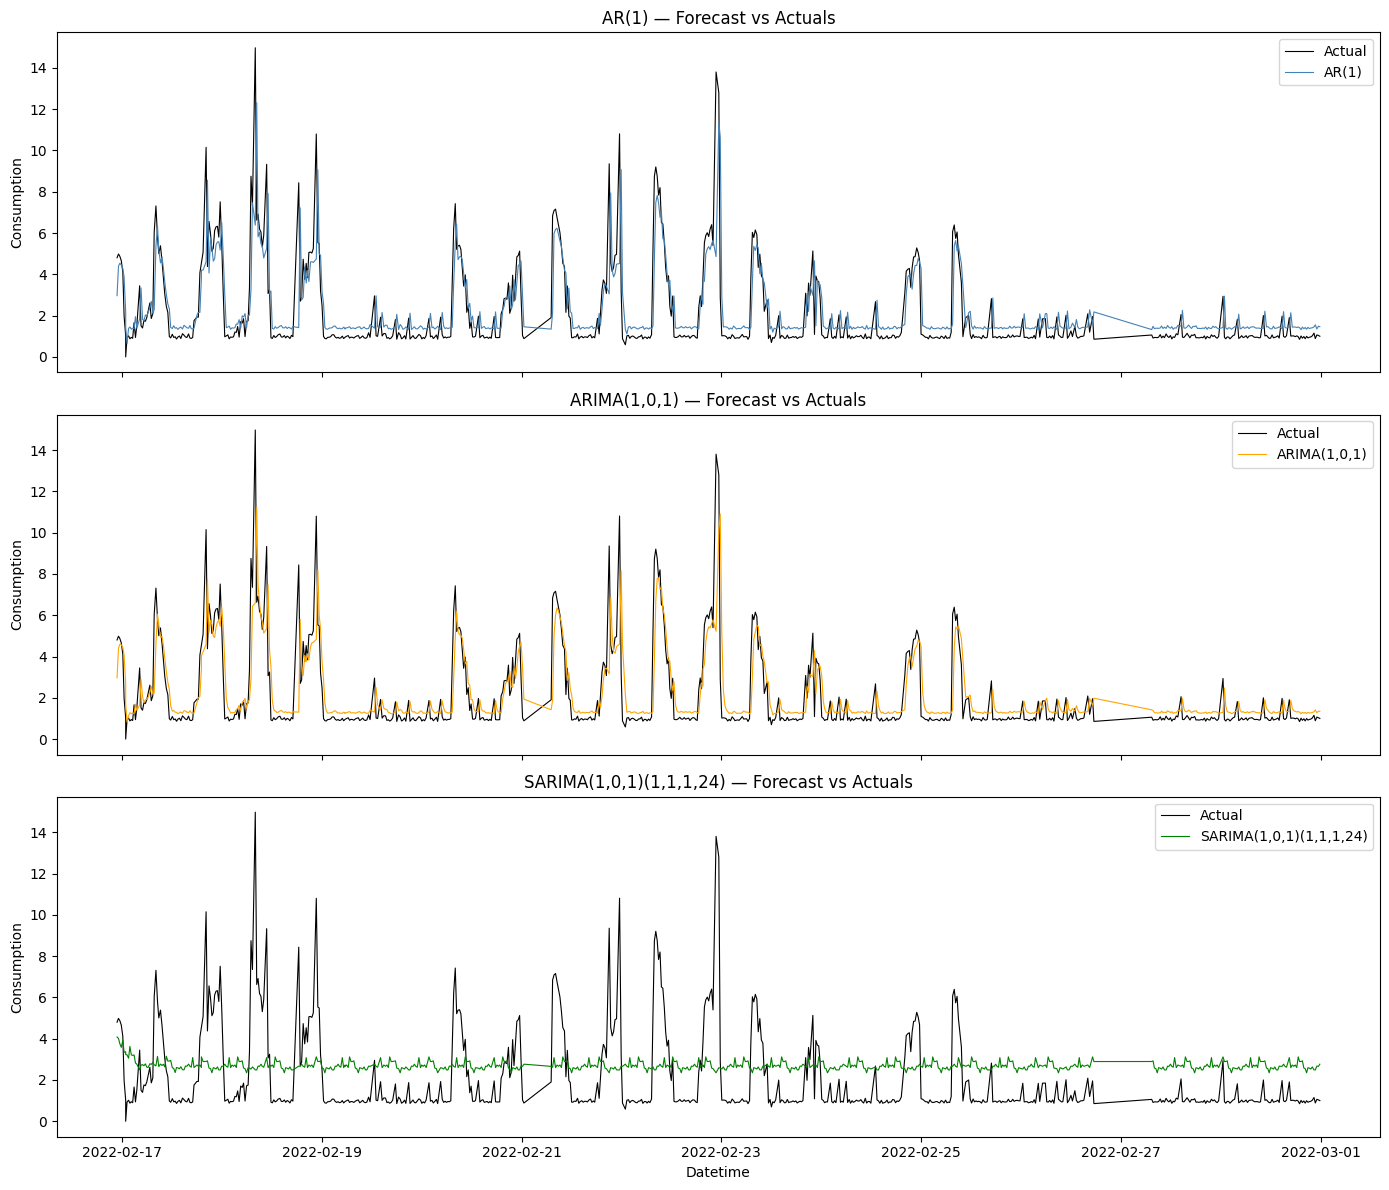

In [94]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

models = [
    (ar_preds,     f"AR({optimal_p})",                          "steelblue"),
    (arima_preds,  f"ARIMA({optimal_p},0,{optimal_q})",         "orange"),
    (sarima_preds, f"SARIMA({optimal_p},0,{optimal_q})(1,1,1,24)", "green"),
]

for ax, (preds, name, color) in zip(axes, models):
    ax.plot(test.index, test.Consumption, label="Actual", color="black", linewidth=0.8)
    ax.plot(test.index, preds,            label=name,     color=color,   linewidth=0.8)
    ax.set_title(f"{name} — Forecast vs Actuals")
    ax.set_ylabel("Consumption")
    ax.legend()

plt.xlabel("Datetime")
plt.tight_layout()
plt.show()

## **Summary:**
> The ACF and PACF of the data shows that there is a high autocorelation at the start of the time-series data because the points at the start wre very high compared to the blue band in the middle. Then, I rerun the AR-p, ARIMA, and SARIMA model. The lowest or best MSE of each model in order were ARIMA, AR-p, and SARIMA. The plot also shows that the predicted values of the models that SARIMA is underperforming.

# Reflection & Reporting Checklist
* Clear description of the raw series (domain, frequency, units).
* Justification of transformations applied for stationarity.
* Code cells reproducible and commented.
* Error-comparison tables include at least MSE; Part 4 also includes AIC.
* Narrative answers all guiding questions, references plots/tables.
* Final paragraph names the overall best forecasting model and defends selection (statistical + practical rationale).

# **Conclusion**
> In this lab activity, I was able to understand how to preprocess the data before performing time-series forecasting. I learn that preprocessing is very crucial in time series data because forecasting models run on mathematics. Furthermore, I learned the different usages of Exponential Smoothing. We cannot use them for all cases, each are specialized for each scenarios or cases. Overall, this lab activity taught me how to do Time-series forecasting from start to finish.